# Heart Disease Prediction using Naive Bayes

This notebook is a cleaned version of my Naive Bayes practice project.

The goal is to predict whether a person has heart disease or not using the `heart.csv` dataset. The target column is `target`, where `1` means heart disease is present and `0` means heart disease is not present.

## 1. Import Libraries

These libraries are used for data handling, visualization, Naive Bayes model training, and evaluation.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

sns.set_theme(style='whitegrid')

## 2. Load Dataset

First, we load the dataset and check the first few rows.

In [2]:
heart_df = pd.read_csv('heart.csv')
heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
heart_df.shape

(303, 14)

In [4]:
heart_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
heart_df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [6]:
heart_df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## 3. Target Distribution

Before training the model, we check how many `0` and `1` values are present in the target column.

In [7]:
heart_df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

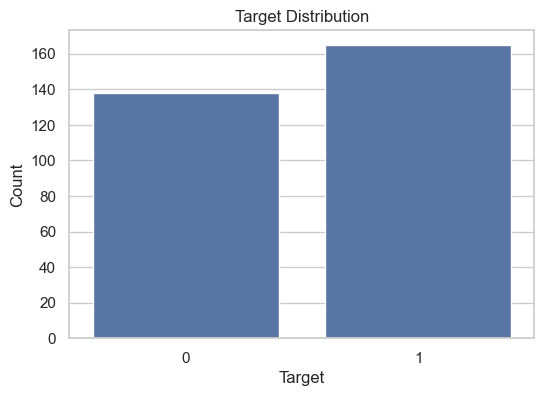

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=heart_df)
plt.title('Target Distribution')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

## 4. Basic EDA

These plots give a simple overview of relationships between some important columns and the target column.

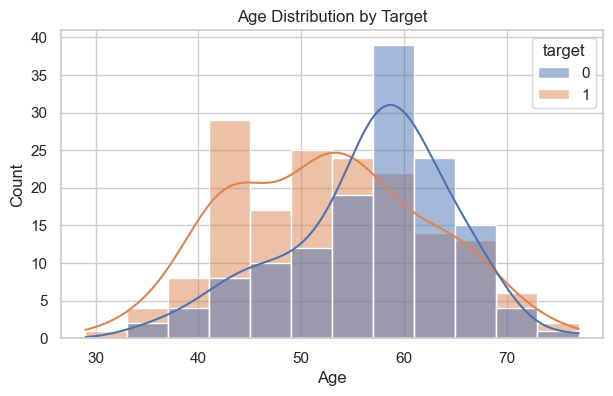

In [9]:
plt.figure(figsize=(7, 4))
sns.histplot(data=heart_df, x='age', hue='target', kde=True)
plt.title('Age Distribution by Target')
plt.xlabel('Age')
plt.show()

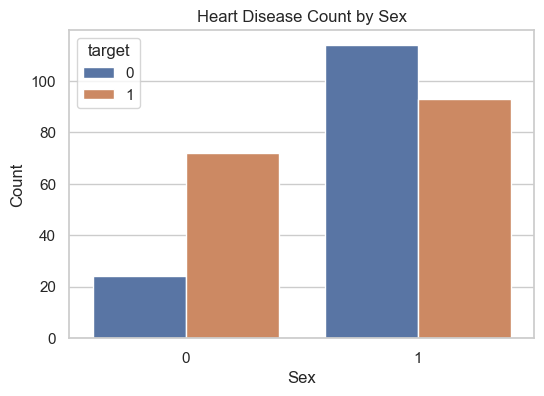

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x='sex', hue='target', data=heart_df)
plt.title('Heart Disease Count by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.show()

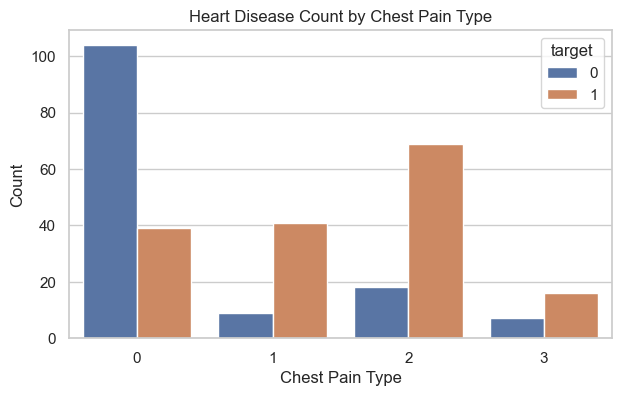

In [11]:
plt.figure(figsize=(7, 4))
sns.countplot(x='cp', hue='target', data=heart_df)
plt.title('Heart Disease Count by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.show()

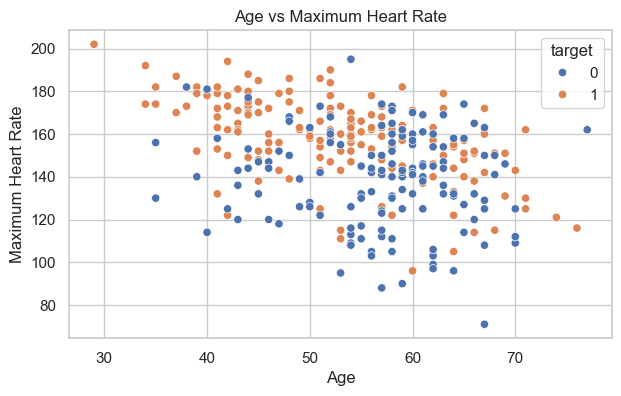

In [12]:
plt.figure(figsize=(7, 4))
sns.scatterplot(x='age', y='thalach', hue='target', data=heart_df)
plt.title('Age vs Maximum Heart Rate')
plt.xlabel('Age')
plt.ylabel('Maximum Heart Rate')
plt.show()

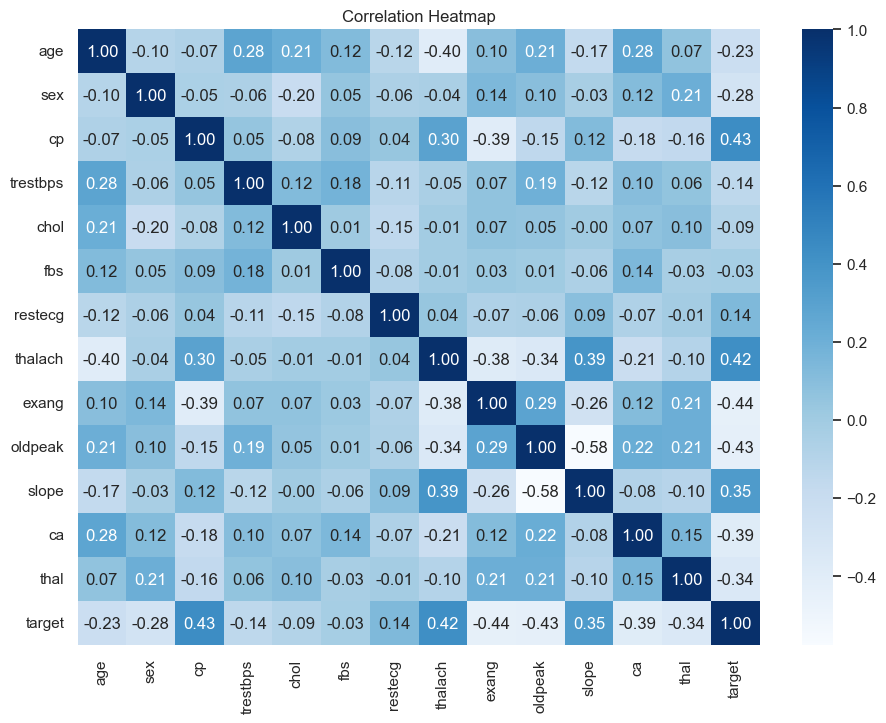

In [13]:
plt.figure(figsize=(11, 8))
sns.heatmap(heart_df.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## 5. Split Data into X and Y

`X` contains input features, and `Y` contains the output column `target`.

In [14]:
X = heart_df.drop(columns='target')
Y = heart_df['target']

X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [15]:
Y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

In [16]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

print('Training data:', X_train.shape)
print('Testing data:', X_test.shape)

Training data: (242, 13)
Testing data: (61, 13)


In [17]:
print('Training target counts:')
print(Y_train.value_counts())

print()
print('Testing target counts:')
print(Y_test.value_counts())

Training target counts:
target
1    133
0    109
Name: count, dtype: int64

Testing target counts:
target
1    32
0    29
Name: count, dtype: int64


## 6. Helper Function for Evaluation

This function prints common classification scores and returns them in dictionary form for final comparison.

In [18]:
def evaluate_classification_model(model_name, y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f'{model_name} Results')
    print(f'Accuracy Score: {accuracy * 100:.2f}%')
    print(f'Precision Score: {precision * 100:.2f}%')
    print(f'Recall Score: {recall * 100:.2f}%')
    print(f'F1 Score: {f1 * 100:.2f}%')
    print()
    print('Classification Report:')
    print(classification_report(y_test, y_pred))

    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
    }

## 7. Train Naive Bayes Model

Now we train the Naive Bayes model using `GaussianNB`.

No scaling is used here, because the original practice notebook was focused on applying Gaussian Naive Bayes directly to the dataset.

In [19]:
gnb_model = GaussianNB()
gnb_model.fit(X_train, Y_train)

Y_pred = gnb_model.predict(X_test)

In [20]:
naive_bayes_result = evaluate_classification_model(
    'Gaussian Naive Bayes',
    Y_test,
    Y_pred
)

Gaussian Naive Bayes Results
Accuracy Score: 86.89%
Precision Score: 90.00%
Recall Score: 84.38%
F1 Score: 87.10%

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



In [21]:
cm = confusion_matrix(Y_test, Y_pred)
print(cm)

[[26  3]
 [ 5 27]]


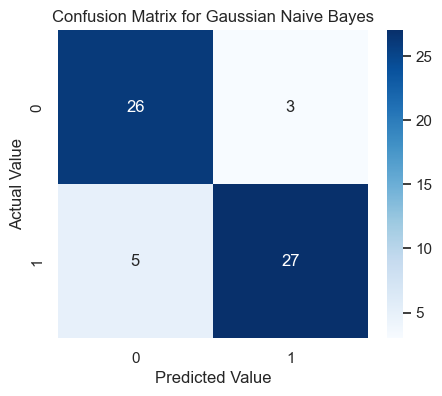

In [22]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Gaussian Naive Bayes')
plt.xlabel('Predicted Value')
plt.ylabel('Actual Value')
plt.show()

## 8. Final Result

This table shows the final model scores.

In [23]:
results_df = pd.DataFrame([naive_bayes_result])
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Gaussian Naive Bayes,0.868852,0.9,0.84375,0.870968


## 9. Final Notes

The Gaussian Naive Bayes model performed well on this heart disease dataset. The main focus of this project was to practice a simple classification workflow: data checking, EDA, train/test split, model training, prediction, evaluation scores, and confusion matrix visualization.